# Assignment 1: Sampler Synthesis — Starter Code

This notebook provides baseline implementations of Random Walk Metropolis-Hastings and HMC using [BlackJAX](https://blackjax-devs.github.io/blackjax/). Use these as reference points for your novel sampler.

**Your task**: Design, implement, and analyze a novel MCMC sampler. Compare it to these baselines on the benchmark distributions.

In [2]:
!pip install blackjax
import arviz as az
import blackjax
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 54.1 MB/s eta 0:00:00


---
## Benchmark Distribution: Rosenbrock (Banana)

The Rosenbrock distribution has a curved, narrow ridge that tests how well samplers handle strong correlations and curved geometry. This is challenging because:
- The high-probability region is thin and curved
- Random walk proposals often step off the ridge
- Samplers need to follow the curved geometry efficiently

In [3]:
def log_prob_rosenbrock(theta):
    """Rosenbrock (banana) distribution.

    log p(x, y) ∝ -(1-x)²/20 - (y - x²)²

    This creates a curved, banana-shaped distribution that tests
    how well samplers handle strong correlations and curved geometry.
    """
    x, y = theta[0], theta[1]
    return -0.05 * (1 - x) ** 2 - (y - x**2) ** 2

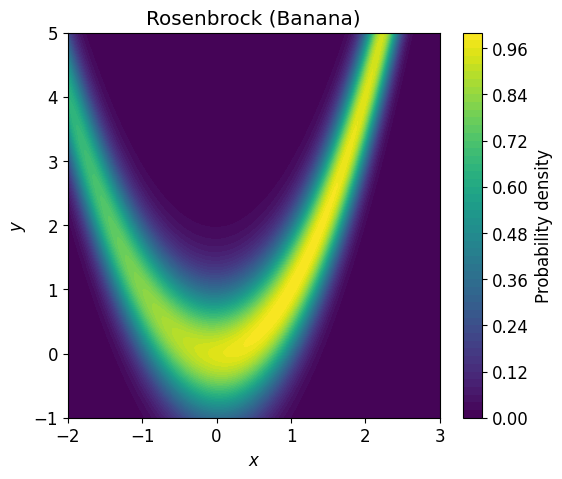

In [4]:
def plot_distribution(log_prob_fn, title, xlim=(-4, 4), ylim=(-4, 4)):
    """Visualize a 2D log probability distribution."""
    x = jnp.linspace(*xlim, 200)
    y = jnp.linspace(*ylim, 200)
    X, Y = jnp.meshgrid(x, y)
    positions = jnp.stack([X.ravel(), Y.ravel()], axis=-1)

    log_probs = jax.vmap(log_prob_fn)(positions).reshape(X.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(X, Y, jnp.exp(log_probs), levels=50, cmap="viridis")
    plt.colorbar(label="Probability density")
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.title(title)
    plt.show()


plot_distribution(log_prob_rosenbrock, "Rosenbrock (Banana)", xlim=(-2, 3), ylim=(-1, 5))

---
## Baseline 1: Random Walk Metropolis-Hastings

The simplest MCMC method. Proposes isotropic Gaussian steps — no gradient information.

**Tuning tip:** Target ~23-50% acceptance rate. Higher isn't better — it means steps are too small.

In [5]:
def run_rwmh(key, log_prob_fn, initial_position, sigma, n_samples):
    """Run Random Walk Metropolis-Hastings using BlackJAX.

    Args:
        key: JAX random key
        log_prob_fn: Log probability function
        initial_position: Starting point, shape (D,)
        sigma: Proposal standard deviation (scalar or array)
        n_samples: Number of samples to draw

    Returns:
        samples: Array of shape (n_samples, D)
        acceptance_rate: Fraction of accepted proposals
    """
    # Initialize the sampler with a normal proposal distribution
    rmh = blackjax.additive_step_random_walk(log_prob_fn, blackjax.mcmc.random_walk.normal(sigma))
    initial_state = rmh.init(initial_position)

    # Build the sampling loop
    @jax.jit
    def one_step(state, key):
        state, info = rmh.step(key, state)
        return state, (state.position, info.is_accepted)

    # Run the chain
    keys = jr.split(key, n_samples)
    _, (samples, accepted) = jax.lax.scan(one_step, initial_state, keys)

    return samples, accepted.mean()

---
## Baseline 2: Hamiltonian Monte Carlo (HMC)

Uses gradient information to make informed proposals. Typically much more efficient than random walk.

**Tuning tip:** Target ~65-90% acceptance rate. Tune step_size first, then n_leapfrog.

In [6]:
def run_hmc(key, log_prob_fn, initial_position, step_size, n_leapfrog, n_samples):
    """Run HMC using BlackJAX.

    Args:
        key: JAX random key
        log_prob_fn: Log probability function
        initial_position: Starting point, shape (D,)
        step_size: Leapfrog step size (epsilon)
        n_leapfrog: Number of leapfrog steps per iteration
        n_samples: Number of samples to draw

    Returns:
        samples: Array of shape (n_samples, D)
        acceptance_rate: Fraction of accepted proposals
    """
    # Initialize the sampler (identity mass matrix)
    inverse_mass_matrix = jnp.ones(initial_position.shape[0])
    hmc = blackjax.hmc(
        log_prob_fn,
        step_size=step_size,
        inverse_mass_matrix=inverse_mass_matrix,
        num_integration_steps=n_leapfrog,
    )
    initial_state = hmc.init(initial_position)

    # Build the sampling loop
    @jax.jit
    def one_step(state, key):
        state, info = hmc.step(key, state)
        return state, (state.position, info.acceptance_rate)

    # Run the chain
    keys = jr.split(key, n_samples)
    _, (samples, accepted) = jax.lax.scan(one_step, initial_state, keys)

    return samples, accepted.mean()

---
## Run Baselines on Rosenbrock

In [7]:
key = jr.PRNGKey(42)
key1, key2 = jr.split(key)

initial_pos = jnp.array([0.0, 0.0])
n_samples = 50_000

# Random Walk MH
rwmh_samples, rwmh_acc = run_rwmh(key1, log_prob_rosenbrock, initial_pos, sigma=1.0, n_samples=n_samples)
print(f"RWMH acceptance rate: {rwmh_acc:.2%}")

# HMC
hmc_samples, hmc_acc = run_hmc(
    key2, log_prob_rosenbrock, initial_pos, step_size=0.2, n_leapfrog=10, n_samples=n_samples
)
print(f"HMC acceptance rate: {hmc_acc:.2%}")

RWMH acceptance rate: 10.38%
HMC acceptance rate: 74.78%


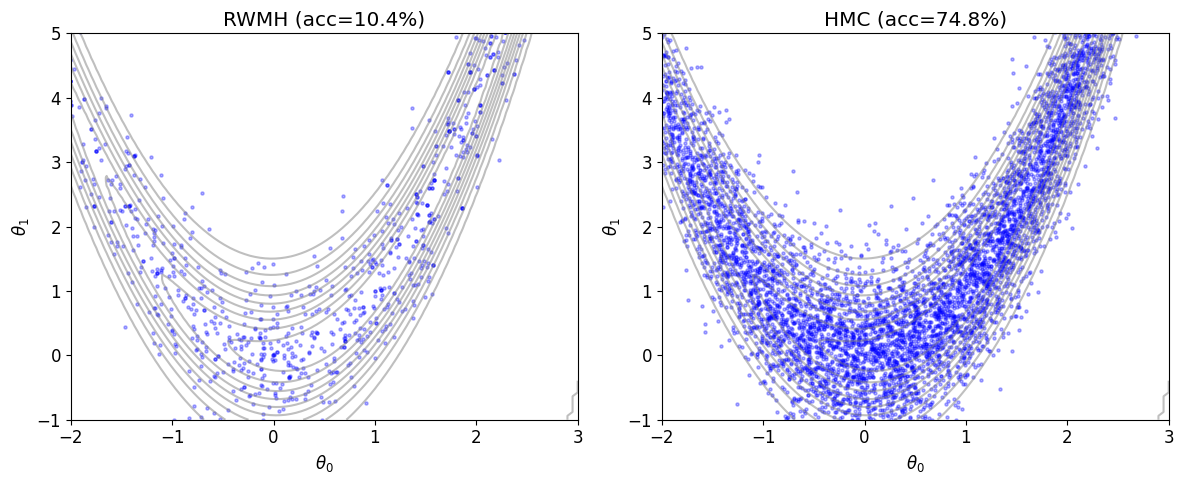

In [8]:
def plot_samples_comparison(samples1, samples2, label1, label2, log_prob_fn, xlim, ylim):
    """Plot samples from two methods side by side."""
    # Compute contours
    x = jnp.linspace(*xlim, 100)
    y = jnp.linspace(*ylim, 100)
    X, Y = jnp.meshgrid(x, y)
    positions = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
    log_probs = jax.vmap(log_prob_fn)(positions).reshape(X.shape)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, samples, label in zip(axes, [samples1, samples2], [label1, label2]):
        ax.contour(X, Y, jnp.exp(log_probs), levels=10, colors="gray", alpha=0.5)
        ax.scatter(samples[::5, 0], samples[::5, 1], alpha=0.3, s=5, c="blue")
        ax.set_xlabel(r"$\theta_0$")
        ax.set_ylabel(r"$\theta_1$")
        ax.set_title(label)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

    plt.tight_layout()
    plt.show()


plot_samples_comparison(
    rwmh_samples,
    hmc_samples,
    f"RWMH (acc={rwmh_acc:.1%})",
    f"HMC (acc={hmc_acc:.1%})",
    log_prob_rosenbrock,
    xlim=(-2, 3),
    ylim=(-1, 5),
)

---
## Diagnostics with ArviZ

[ArviZ](https://python.arviz.org/) provides standard MCMC diagnostics. Key metrics:
- **Acceptance rate**: Too low = proposals too aggressive; too high = proposals too timid
- **Effective Sample Size (ESS)**: How many independent samples you effectively have
- **Trace plots**: Visual check for mixing and stationarity
- **Autocorrelation**: How correlated successive samples are

In [9]:
def samples_to_inference_data(samples, var_names=None):
    """Convert samples array to ArviZ InferenceData.

    Args:
        samples: Array of shape (n_samples, n_dims)
        var_names: Optional list of variable names

    Returns:
        ArviZ InferenceData object
    """
    if var_names is None:
        var_names = [f"theta_{i}" for i in range(samples.shape[1])]

    # ArviZ expects dict of {var_name: array} with shape (n_chains, n_samples)
    data_dict = {name: samples[None, :, i] for i, name in enumerate(var_names)}
    return az.convert_to_inference_data(data_dict)


def summarize_sampler(samples, name, var_names=None):
    """Print summary statistics for samples using ArviZ."""
    idata = samples_to_inference_data(samples, var_names)
    print(f"\n=== {name} ===")
    display(az.summary(idata, kind="stats"))

In [10]:
# Rosenbrock diagnostics
var_names = ["x", "y"]

rwmh_idata = samples_to_inference_data(rwmh_samples, var_names)
hmc_idata = samples_to_inference_data(hmc_samples, var_names)

# Summary statistics (mean, sd, ESS)
summarize_sampler(rwmh_samples, "RWMH — Rosenbrock", var_names)
summarize_sampler(hmc_samples, "HMC — Rosenbrock", var_names)


=== RWMH — Rosenbrock ===


,mean,sd,hdi_3%,hdi_97%
x,5.555,2.141,0.706,8.087
y,35.447,17.237,-0.248,58.602



=== HMC — Rosenbrock ===


,mean,sd,hdi_3%,hdi_97%
x,0.456,2.202,-3.390,4.018
y,4.970,5.012,-0.379,15.324


RWMH Trace Plots:


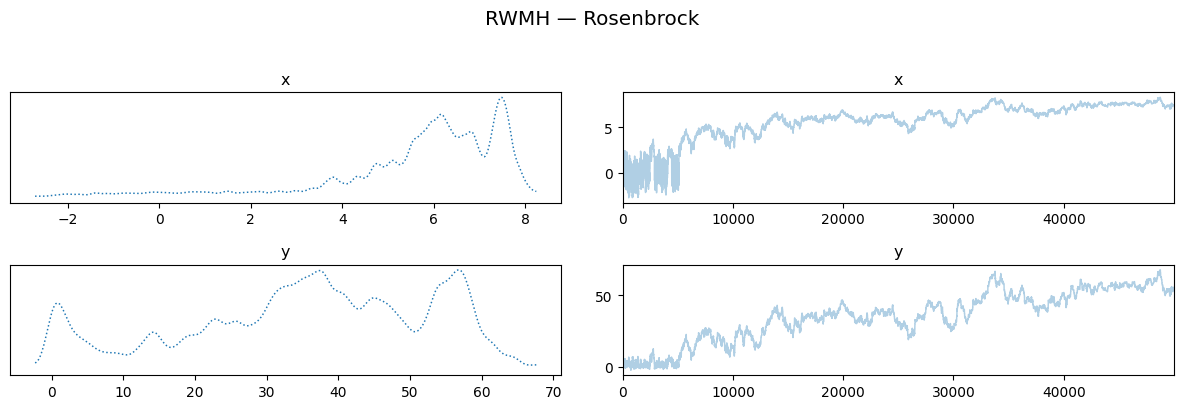


HMC Trace Plots:


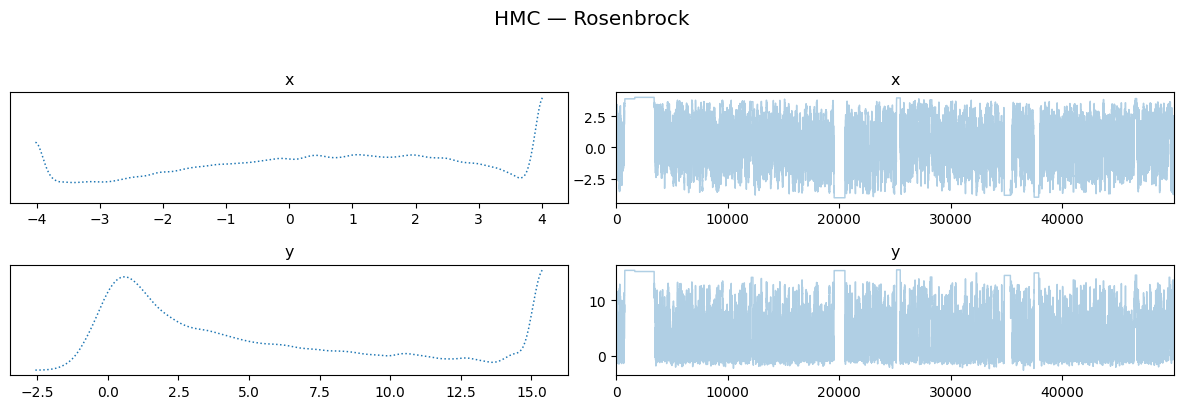

In [11]:
# Trace plots — Rosenbrock
print("RWMH Trace Plots:")
az.plot_trace(rwmh_idata, combined=True, figsize=(12, 4))
plt.suptitle("RWMH — Rosenbrock", y=1.02)
plt.tight_layout()
plt.show()

print("\nHMC Trace Plots:")
az.plot_trace(hmc_idata, combined=True, figsize=(12, 4))
plt.suptitle("HMC — Rosenbrock", y=1.02)
plt.tight_layout()
plt.show()

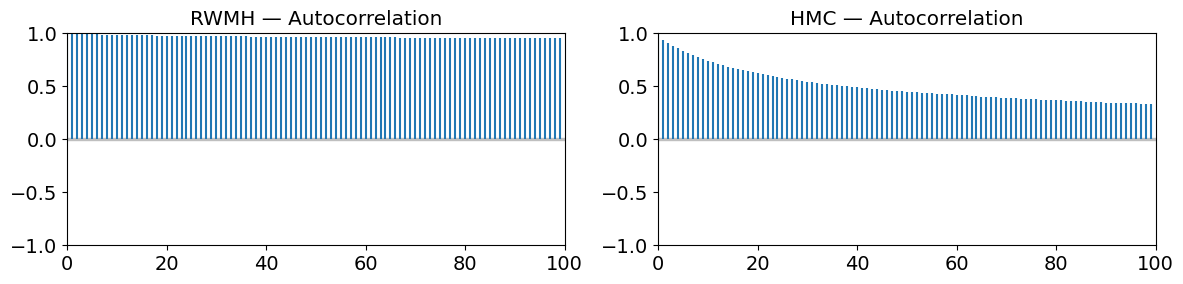

In [12]:
# Autocorrelation — Rosenbrock
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
az.plot_autocorr(rwmh_idata, ax=axes[0], combined=True)
axes[0].set_title("RWMH — Autocorrelation")
az.plot_autocorr(hmc_idata, ax=axes[1], combined=True)
axes[1].set_title("HMC — Autocorrelation")
plt.tight_layout()
plt.show()

---
## Discussion: Why Does RWMH Struggle Here?

Look carefully at the results above. You might notice something surprising: RWMH has *lower* autocorrelation than HMC, yet HMC explores the distribution much better. What's going on?

**The issue is local vs. global mixing.** RWMH with isotropic proposals faces a dilemma on curved distributions like the Rosenbrock:
- If the proposal scale is small enough to stay on the narrow ridge, it can't move far along the banana
- If the proposal scale is large enough to explore, most proposals step off the ridge and get rejected

So RWMH ends up jittering locally — samples decorrelate quickly *within* its local neighborhood, but it never traverses the full banana. Low autocorrelation doesn't mean good exploration!

**HMC uses gradients to follow the curve.** It makes long, coherent moves along the ridge without stepping off. The high autocorrelation is just because consecutive samples are along the same trajectory — but they're actually covering the full posterior.

This is exactly the kind of geometry where HMC shines, and one of the main motivations for gradient-based samplers.

---
## Benchmark Distribution 2: Neal's Funnel

Neal's Funnel is a hierarchical distribution that varies dramatically in scale across the space. The narrow "neck" of the funnel is notoriously difficult for fixed step-size samplers.

$$v \sim \mathcal{N}(0, 9), \quad x \sim \mathcal{N}(0, e^v)$$

This means:
- When $v$ is large and positive, $x$ can vary widely
- When $v$ is large and negative, $x$ is tightly constrained near 0
- A single step size can't work well everywhere

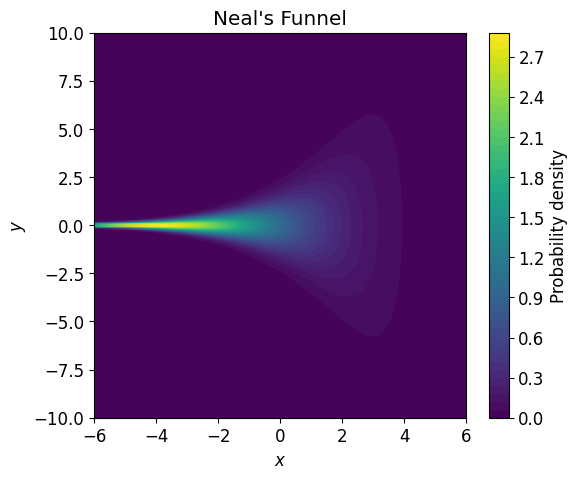

In [13]:
def log_prob_funnel(theta):
    """Neal's Funnel distribution.

    v ~ N(0, 9)
    x ~ N(0, exp(v))

    This creates a funnel shape where the scale of x depends on v.
    The narrow neck (small v) is very hard to sample.
    """
    v, x = theta[0], theta[1]
    log_p_v = -0.5 * v**2 / 9  # v ~ N(0, 9)
    log_p_x_given_v = -0.5 * x**2 * jnp.exp(-v) - 0.5 * v  # x ~ N(0, exp(v))
    return log_p_v + log_p_x_given_v


plot_distribution(log_prob_funnel, "Neal's Funnel", xlim=(-6, 6), ylim=(-10, 10))

In [14]:
# TODO: Run the RWMH and HMC baselines on Neal's Funnel
# Use the same workflow as Rosenbrock above — you'll need to tune hyperparameters!

In [15]:
# Try the two baseline samplers on Neal's Funnel
key = jr.PRNGKey(42)
key1, key2 = jr.split(key)
initial_pos = jnp.array([0.0, 0.0])
n_samples = 50_000

# I used a smaller random walk step because the neck of the funnel is narrow
rwmh_funnel_samples, rwmh_funnel_acc = run_rwmh( key1, log_prob_funnel, initial_pos, sigma = 0.5, n_samples = n_samples)

# A smaller HMC step size was more stable for the funnel
hmc_funnel_samples, hmc_funnel_acc = run_hmc( key2, log_prob_funnel, initial_pos, step_size = 0.1, n_leapfrog = 10, n_samples = n_samples)

print(f"RWMH acceptance rate: {rwmh_funnel_acc:.2%}")
print(f"HMC acceptance rate: {hmc_funnel_acc:.2%}")

RWMH acceptance rate: 73.22%
HMC acceptance rate: 97.41%


---
## Your Novel Sampler

Now it's your turn! Implement your own sampler below. Some ideas:

- **Adaptive proposals**: Adjust step size based on acceptance rate or local curvature
- **Hybrid methods**: Combine different move types (e.g., local + global moves)
- **Modified dynamics**: Change the Hamiltonian, use different integrators, add friction
- **Tempering**: Use temperature schedules to help exploration

A simple idea with thorough analysis beats a complex idea you don't understand!

In [16]:
def run_mutation_hmc(
    key,
    log_prob_fn,
    initial_position,
    step_size,
    n_leapfrog,
    n_samples,
    mutation_scale=3.0,
    mutation_prob=0.05,
):

    # Limiting case:
    # p = 0 should recover the standard HMC baseline exactly.
    if mutation_prob == 0.0:
        return run_hmc(
            key,
            log_prob_fn,
            initial_position,
            step_size,
            n_leapfrog,
            n_samples,
        )

    # Standard HMC setup
    inverse_mass_matrix = jnp.ones(initial_position.shape[0])

    hmc = blackjax.hmc(
        log_prob_fn,
        step_size=step_size,
        inverse_mass_matrix=inverse_mass_matrix,
        num_integration_steps=n_leapfrog,
    )

    initial_state = hmc.init(initial_position)

    # One Mutation-HMC iteration
    @jax.jit
    def one_step(state, key):

        # Split random keys
        key_hmc, key_choose, key_mutation, key_accept = jr.split(key, 4)

        # 1. Standard HMC transition
        hmc_state, hmc_info = hmc.step(key_hmc, state)

        # 2. Decide whether to attempt a mutation
        do_mutation = jr.uniform(key_choose) < mutation_prob

        # Heavy-tailed Cauchy proposal
        mutation = mutation_scale * jr.cauchy(
            key_mutation,
            shape=hmc_state.position.shape,
        )

        proposed_position = hmc_state.position + mutation

        # 3. Metropolis-Hastings acceptance probability
        log_alpha = (
            log_prob_fn(proposed_position)
            - log_prob_fn(hmc_state.position)
        )

        accept_mutation = (
            jnp.log(jr.uniform(key_accept))
            < jnp.minimum(0.0, log_alpha)
        )

        # Mutation is accepted only when it was selected
        # and passed the MH acceptance test
        use_mutation = do_mutation & accept_mutation

        final_position = jnp.where(
            use_mutation,
            proposed_position,
            hmc_state.position,
        )

        # Rebuild a valid HMC state at the final position
        final_state = hmc.init(final_position)

        # Record whether the overall iteration moved
        overall_acceptance = jnp.where(
            do_mutation,
            accept_mutation.astype(jnp.float32),
            hmc_info.acceptance_rate,
        )

        return final_state, (
            final_position,
            overall_acceptance,
        )

    # Run chain
    keys = jr.split(key, n_samples)

    _, (samples, accepted) = jax.lax.scan(
        one_step,
        initial_state,
        keys,
    )

    return samples, accepted.mean()

In [17]:
# TODO: Test your sampler on both benchmarks (Rosenbrock and Neal's Funnel)
# my_samples, my_acc = run_my_sampler(key, log_prob_rosenbrock, initial_pos, n_samples=50_000, ...)

In [18]:
key = jr.PRNGKey(42)

my_samples, my_acc = run_mutation_hmc(
    key,
    log_prob_rosenbrock,
    initial_pos,
    step_size=0.2,
    n_leapfrog=10,
    n_samples=n_samples,
    mutation_scale=3.0,
    mutation_prob=0.05,
)

print(f"Mutation HMC acceptance rate: {my_acc:.2%}")

Mutation HMC acceptance rate: 60.07%


In [19]:
# TODO: Test your sampler on Rosenbrock
# my_samples, my_acc = run_my_sampler(key, log_prob_rosenbrock, initial_pos, n_samples=50_000, ...)

In [20]:
key = jr.PRNGKey(42)

my_funnel_samples, my_funnel_acc = run_mutation_hmc(
    key,
    log_prob_funnel,
    initial_pos,
    step_size=0.1,
    n_leapfrog=10,
    n_samples=n_samples,
    mutation_scale=3.0,
    mutation_prob=0.05,
)

print(f"Mutation HMC Funnel acceptance rate: {my_funnel_acc:.2%}")

Mutation HMC Funnel acceptance rate: 90.87%


In [21]:
# TODO: Compare to baselines
# - Visualize samples (scatter plot with contours)
# - Compute ESS using samples_to_inference_data() and az.summary()
# - Plot traces and autocorrelation
# - Discuss: where does your method work well? Where does it struggle?

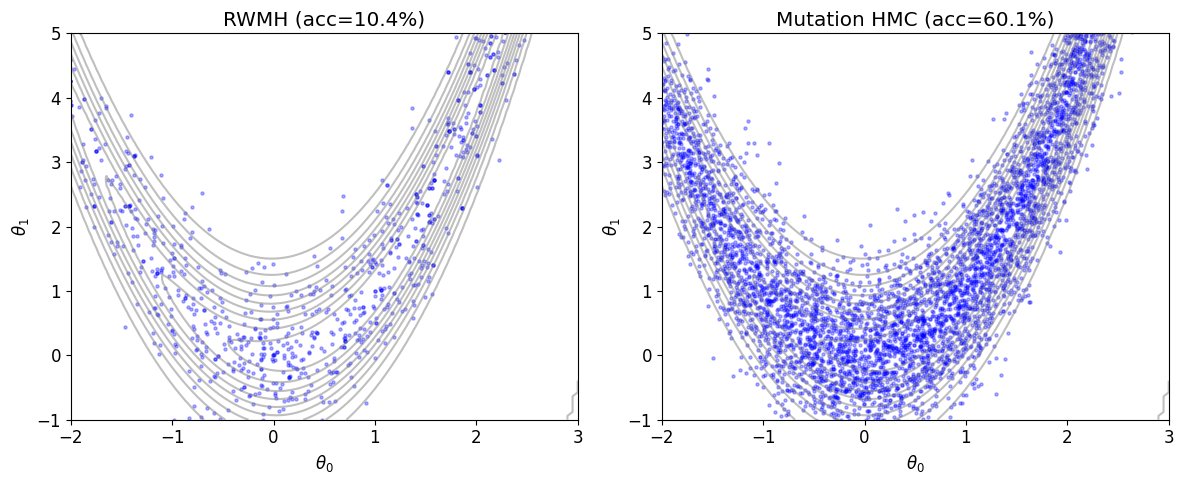

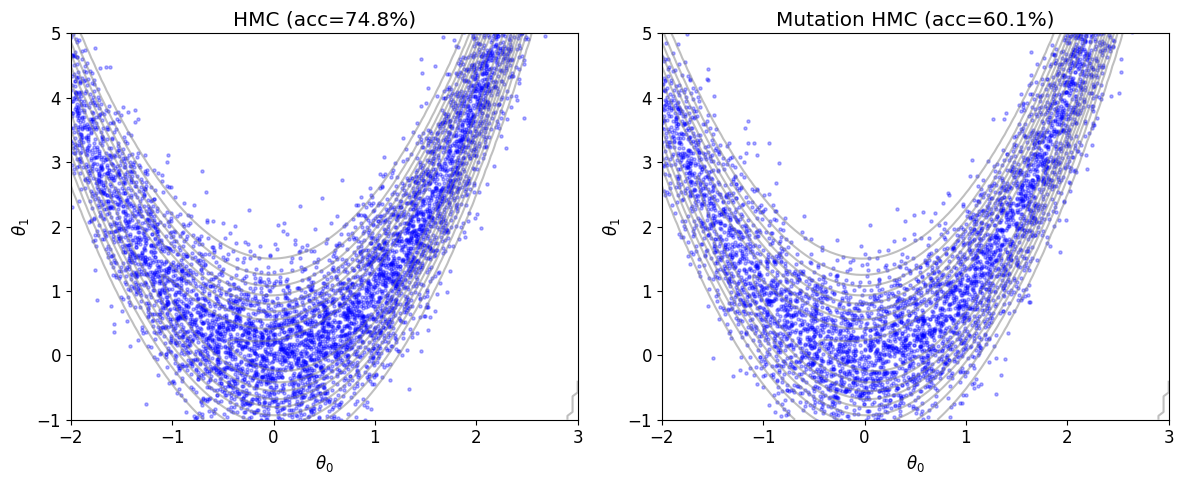

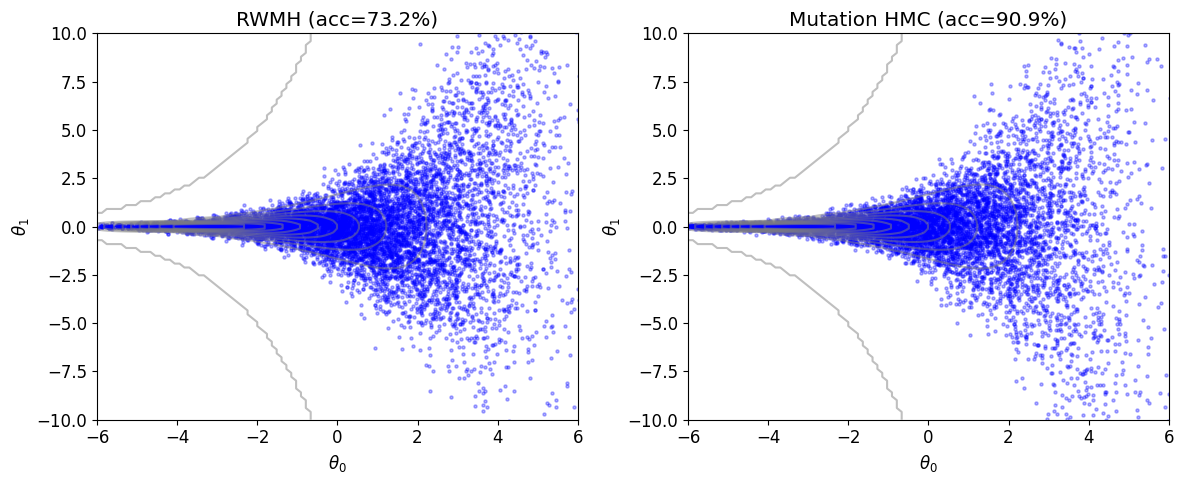

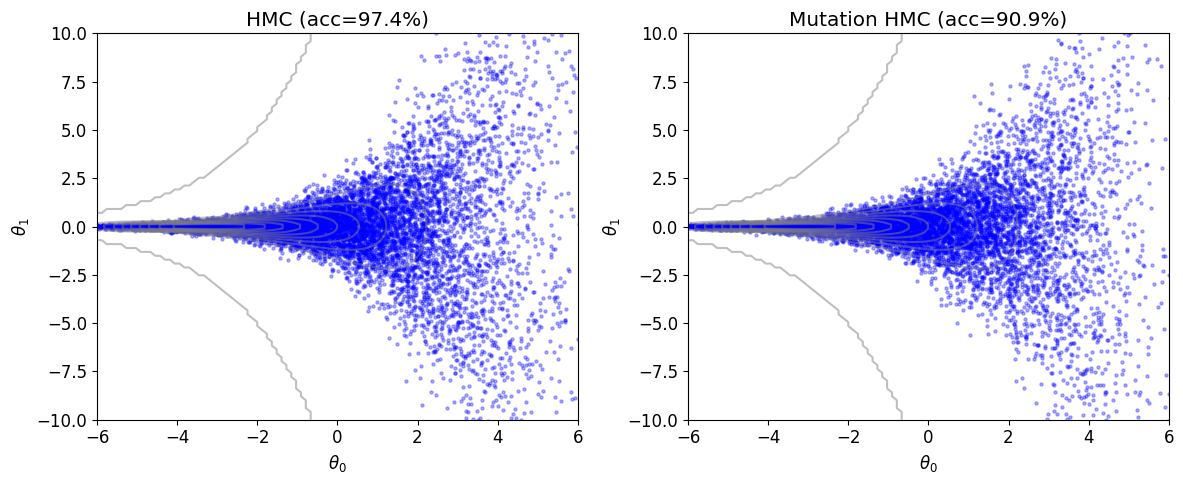

In [22]:
plot_samples_comparison(
    rwmh_samples,
    my_samples,
    f"RWMH (acc={rwmh_acc:.1%})",
    f"Mutation HMC (acc={my_acc:.1%})",
    log_prob_rosenbrock,
    xlim=(-2, 3),
    ylim=(-1, 5),
)

plot_samples_comparison(
    hmc_samples,
    my_samples,
    f"HMC (acc={hmc_acc:.1%})",
    f"Mutation HMC (acc={my_acc:.1%})",
    log_prob_rosenbrock,
    xlim=(-2, 3),
    ylim=(-1, 5),
)

plot_samples_comparison(
    rwmh_funnel_samples,
    my_funnel_samples,
    f"RWMH (acc={rwmh_funnel_acc:.1%})",
    f"Mutation HMC (acc={my_funnel_acc:.1%})",
    log_prob_funnel,
    xlim=(-6, 6),
    ylim=(-10, 10),
)

plot_samples_comparison(
    hmc_funnel_samples,
    my_funnel_samples,
    f"HMC (acc={hmc_funnel_acc:.1%})",
    f"Mutation HMC (acc={my_funnel_acc:.1%})",
    log_prob_funnel,
    xlim=(-6, 6),
    ylim=(-10, 10),
)

In [23]:
var_names = ["x", "y"]

summarize_sampler(
    rwmh_samples,
    "RWMH - Rosenbrock",
    var_names,
)

summarize_sampler(
    hmc_samples,
    "HMC - Rosenbrock",
    var_names,
)

summarize_sampler(
    my_samples,
    "Mutation HMC - Rosenbrock",
    var_names,
)


=== RWMH - Rosenbrock ===


,mean,sd,hdi_3%,hdi_97%
x,5.555,2.141,0.706,8.087
y,35.447,17.237,-0.248,58.602



=== HMC - Rosenbrock ===


,mean,sd,hdi_3%,hdi_97%
x,0.456,2.202,-3.390,4.018
y,4.970,5.012,-0.379,15.324



=== Mutation HMC - Rosenbrock ===


,mean,sd,hdi_3%,hdi_97%
x,-0.215,2.939,-5.024,4.264
y,8.697,9.889,-0.728,25.083


In [24]:
funnel_var_names = ["v", "x"]

summarize_sampler(
    rwmh_funnel_samples,
    "RWMH - Funnel",
    funnel_var_names,
)

summarize_sampler(
    hmc_funnel_samples,
    "HMC - Funnel",
    funnel_var_names,
)

summarize_sampler(
    my_funnel_samples,
    "Mutation HMC - Funnel",
    funnel_var_names,
)


=== RWMH - Funnel ===


,mean,sd,hdi_3%,hdi_97%
v,0.521,2.872,-4.797,5.869
x,1.507,5.911,-6.180,14.105



=== HMC - Funnel ===


,mean,sd,hdi_3%,hdi_97%
v,0.188,2.994,-5.493,5.925
x,-1.391,8.563,-10.023,10.904



=== Mutation HMC - Funnel ===


,mean,sd,hdi_3%,hdi_97%
v,0.269,3.490,-6.767,6.718
x,-3.554,19.186,-22.111,27.725


In [25]:
def print_ess(samples, name, var_names):
    idata = samples_to_inference_data(samples, var_names)
    ess = az.ess(idata)

    print(f"\n=== ESS: {name} ===")
    display(ess)


# Rosenbrock
print_ess(rwmh_samples, "RWMH - Rosenbrock", ["x", "y"])
print_ess(hmc_samples, "HMC - Rosenbrock", ["x", "y"])
print_ess(my_samples, "Mutation HMC - Rosenbrock", ["x", "y"])

# Funnel
print_ess(rwmh_funnel_samples, "RWMH - Funnel", ["v", "x"])
print_ess(hmc_funnel_samples, "HMC - Funnel", ["v", "x"])
print_ess(my_funnel_samples, "Mutation HMC - Funnel", ["v", "x"])


=== ESS: RWMH - Rosenbrock ===


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    x        float64 8B 1.545
    y        float64 8B 1.544
Attributes:
    created_at:     2026-10-05T13:49:37.386791+00:00
    arviz_version:  0.22.0


=== ESS: HMC - Rosenbrock ===


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    x        float64 8B 41.64
    y        float64 8B 93.39
Attributes:
    created_at:     2026-10-05T13:49:38.062016+00:00
    arviz_version:  0.22.0


=== ESS: Mutation HMC - Rosenbrock ===


...

<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    v        float64 8B 62.08
    x        float64 8B 46.83
Attributes:
    created_at:     2026-10-05T13:49:38.474960+00:00
    arviz_version:  0.22.0


=== ESS: HMC - Funnel ===


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    v        float64 8B 208.6
    x        float64 8B 152.6
Attributes:
    created_at:     2026-10-05T13:49:38.600743+00:00
    arviz_version:  0.22.0


=== ESS: Mutation HMC - Funnel ===


<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    v        float64 8B 73.1
    x        float64 8B 62.62
Attributes:
    created_at:     2026-10-05T13:49:38.701019+00:00
    arviz_version:  0.22.0

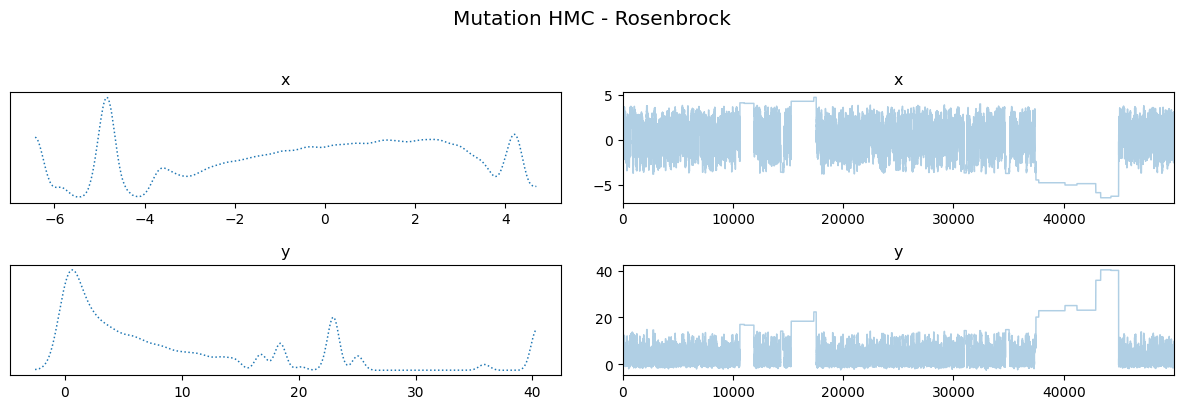

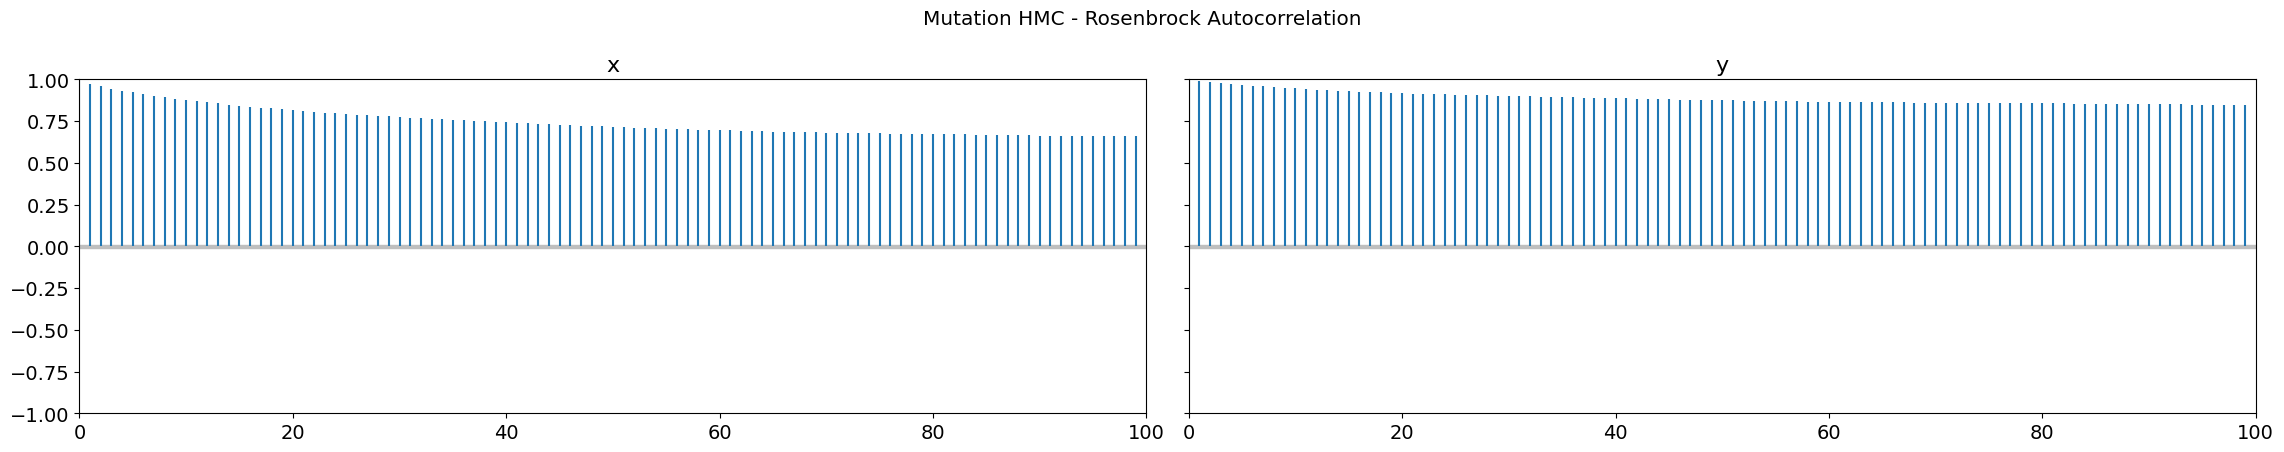

In [26]:
# Mutation HMC diagnostics - Rosenbrock
mutation_idata = samples_to_inference_data(
    my_samples,
    ["x", "y"]
)

az.plot_trace(
    mutation_idata,
    combined=True,
    figsize=(12, 4)
)
plt.suptitle("Mutation HMC - Rosenbrock", y=1.02)
plt.tight_layout()
plt.show()

az.plot_autocorr(
    mutation_idata,
    combined=True
)
plt.suptitle("Mutation HMC - Rosenbrock Autocorrelation")
plt.tight_layout()
plt.show()

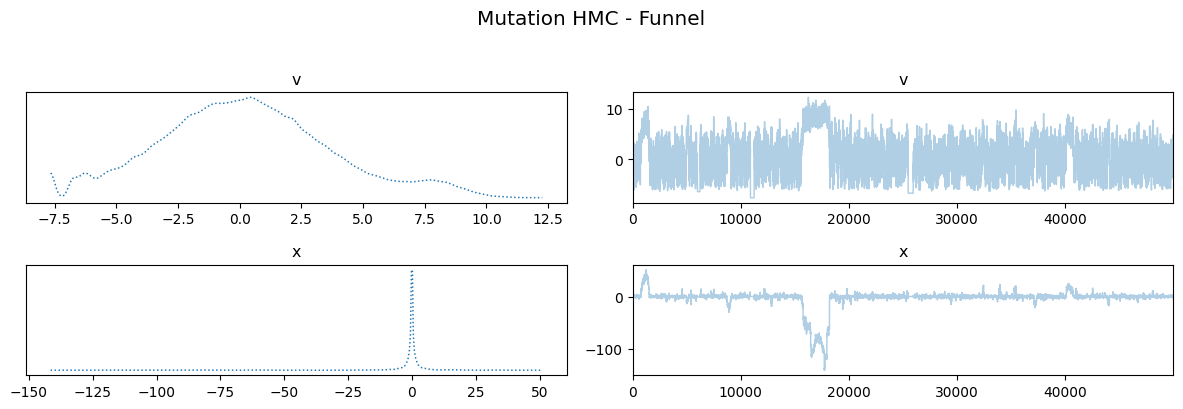

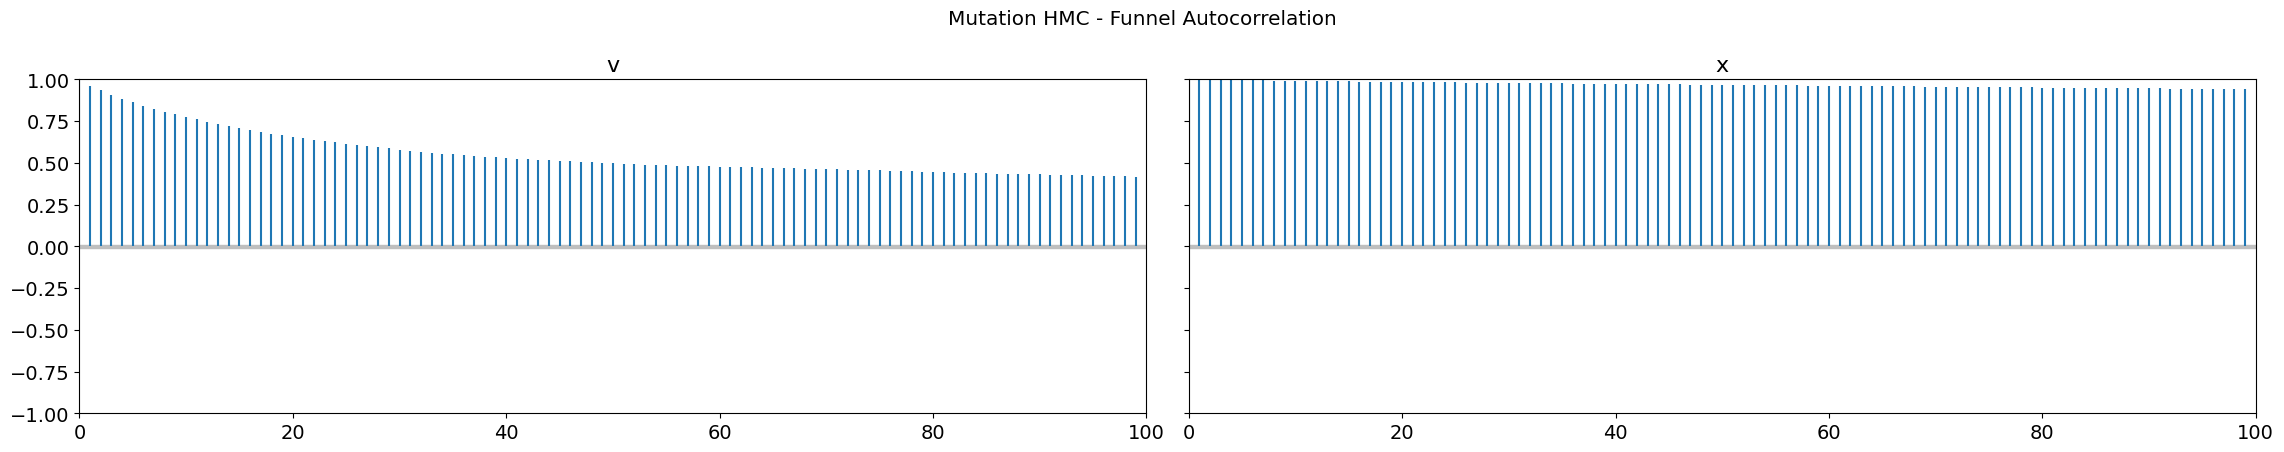

In [27]:
mutation_funnel_idata = samples_to_inference_data(
    my_funnel_samples,
    ["v", "x"]
)

az.plot_trace(
    mutation_funnel_idata,
    combined=True,
    figsize=(12, 4)
)
plt.suptitle("Mutation HMC - Funnel", y=1.02)
plt.tight_layout()
plt.show()

az.plot_autocorr(
    mutation_funnel_idata,
    combined=True
)
plt.suptitle("Mutation HMC - Funnel Autocorrelation")
plt.tight_layout()
plt.show()

In [28]:
# TODO: Ablation study
# - What are the key hyperparameters of your method?
# - How sensitive is performance to each one?
# - What happens in limiting cases (e.g., turning off a component)?

In [29]:
# Ablation study: mutation probability

mutation_probs = [0.0, 0.01, 0.05, 0.10, 0.20]

prob_results = []

for p in mutation_probs:

    key = jr.PRNGKey(42)

    samples, acc = run_mutation_hmc(
        key,
        log_prob_rosenbrock,
        initial_pos,
        step_size=0.2,
        n_leapfrog=10,
        n_samples=50_000,
        mutation_scale=3.0,
        mutation_prob=p,
    )

    idata = samples_to_inference_data(
        samples,
        ["x", "y"],
    )

    ess = az.ess(idata)

    prob_results.append({
        "mutation_prob": p,
        "acceptance": float(acc),
        "ess_x": float(ess["x"].values),
        "ess_y": float(ess["y"].values),
        "sd_x": float(jnp.std(samples[:, 0])),
        "sd_y": float(jnp.std(samples[:, 1])),
    })


for result in prob_results:
    print(result)

{'mutation_prob': 0.0, 'acceptance': 0.7635074853897095, 'ess_x': 172.99062755050713, 'ess_y': 204.63308545368832, 'sd_x': 2.1403720378875732, 'sd_y': 4.732601642608643}
{'mutation_prob': 0.01, 'acceptance': 0.7891173362731934, 'ess_x': 246.98392698043455, 'ess_y': 352.5580058830722, 'sd_x': 2.023977756500244, 'sd_y': 4.369521141052246}
{'mutation_prob': 0.05, 'acceptance': 0.6007468104362488, 'ess_x': 5.928531474808325, 'ess_y': 17.834598368502185, 'sd_x': 2.9392948150634766, 'sd_y': 9.889262199401855}
{'mutation_prob': 0.1, 'acceptance': 0.5175832509994507, 'ess_x': 8.291631817535954, 'ess_y': 6.1918358718773945, 'sd_x': 2.551541328430176, 'sd_y': 9.113457679748535}
{'mutation_prob': 0.2, 'acceptance': 0.5688604712486267, 'ess_x': 78.57303910315154, 'ess_y': 74.35110937868585, 'sd_x': 2.4071829319000244, 'sd_y': 7.737248420715332}


In [30]:
# Ablation study: mutation scale

mutation_scales = [1.0, 2.0, 3.0, 5.0]

scale_results = []

for scale in mutation_scales:

    key = jr.PRNGKey(42)

    samples, acc = run_mutation_hmc(
        key,
        log_prob_rosenbrock,
        initial_pos,
        step_size=0.2,
        n_leapfrog=10,
        n_samples=50_000,
        mutation_scale=scale,
        mutation_prob=0.05,
    )

    idata = samples_to_inference_data(
        samples,
        ["x", "y"],
    )

    ess = az.ess(idata)

    scale_results.append({
        "mutation_scale": scale,
        "acceptance": float(acc),
        "ess_x": float(ess["x"].values),
        "ess_y": float(ess["y"].values),
        "sd_x": float(jnp.std(samples[:, 0])),
        "sd_y": float(jnp.std(samples[:, 1])),
    })


for result in scale_results:
    print(result)

{'mutation_scale': 1.0, 'acceptance': 0.5939587950706482, 'ess_x': 12.920213814276345, 'ess_y': 15.39901548658848, 'sd_x': 2.7085766792297363, 'sd_y': 7.552612781524658}
{'mutation_scale': 2.0, 'acceptance': 0.5873361825942993, 'ess_x': 11.915165252846775, 'ess_y': 3.898441712089554, 'sd_x': 2.8707520961761475, 'sd_y': 12.268835067749023}
{'mutation_scale': 3.0, 'acceptance': 0.6007468104362488, 'ess_x': 5.928531474808325, 'ess_y': 17.834598368502185, 'sd_x': 2.9392948150634766, 'sd_y': 9.889262199401855}
{'mutation_scale': 5.0, 'acceptance': 0.7008280158042908, 'ess_x': 35.8584915062407, 'ess_y': 37.788813448765886, 'sd_x': 2.177811622619629, 'sd_y': 5.827372074127197}
